In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

df= sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [22]:
df=df.drop(columns='species')
df.shape

(150, 4)

In [23]:
df.corr()
#df.corr(numeric_only=True)#here we are checking only for numaric values

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


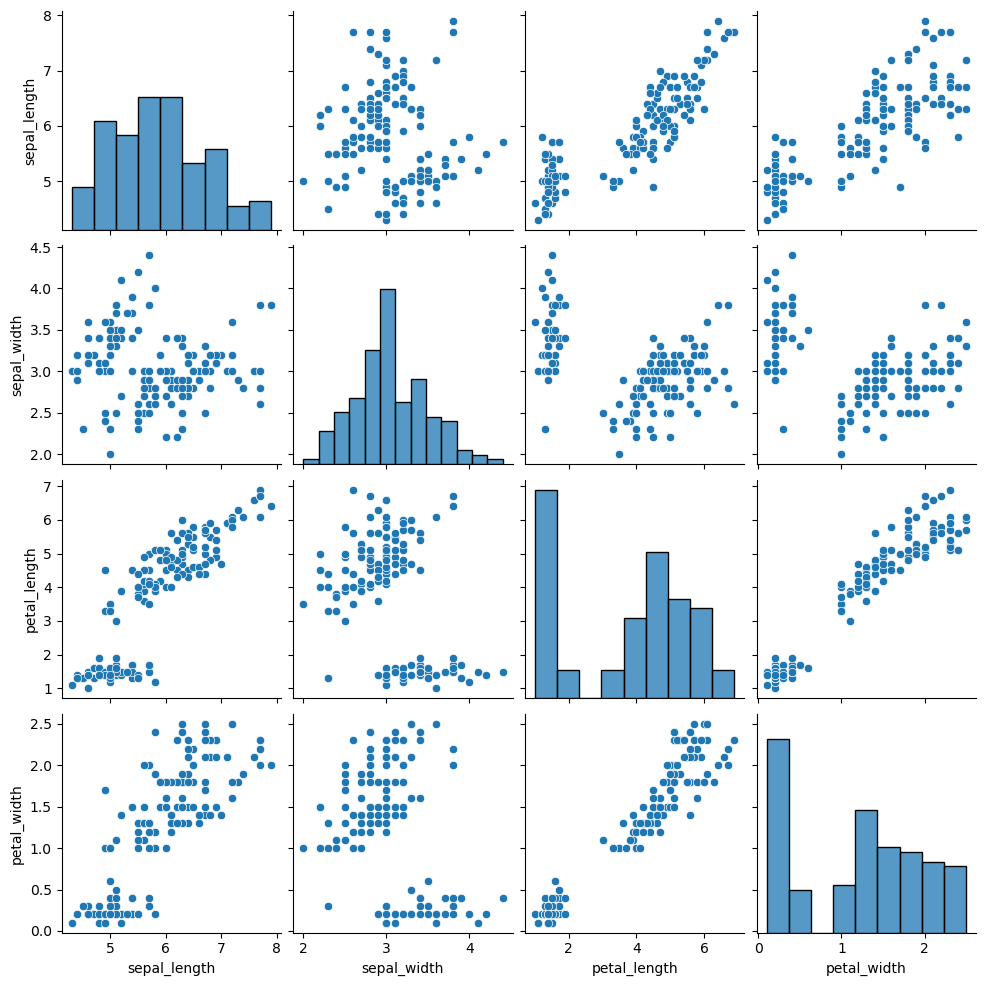

In [24]:
sns.pairplot(df)

# Another sample 

In [37]:
#Dataset
data = {
    'study_hours': [2, 4, 6, 8, 10, 3, 7, 5, 9, 1],
    'exam_score':  [50, 65, 75, 85, 95, 55, 80, 70, 90, 40],
    'sleep_hours': [8, 7, 6, 6, 5, 8, 6, 7, 5, 9],
    'stress_level':[3, 4, 5, 6, 8, 3, 6, 5, 7, 2],
}
df_study = pd.DataFrame(data)
df_study

,study_hours,exam_score,sleep_hours,stress_level
0,2,50,8,3
1,4,65,7,4
2,6,75,6,5
3,8,85,6,6
4,10,95,5,8
5,3,55,8,3
6,7,80,6,6
7,5,70,7,5
8,9,90,5,7
9,1,40,9,2


In [38]:
#correction
df_study.corr()

,study_hours,exam_score,sleep_hours,stress_level
study_hours,1.000000,0.992820,-0.974066,0.988513
exam_score,0.992820,1.000000,-0.984255,0.985226
sleep_hours,-0.974066,-0.984255,1.000000,-0.968934
stress_level,0.988513,0.985226,-0.968934,1.000000


In [39]:
# ── 1. Covariance ─────────────────────────────────────────────
print("=== COVARIANCE MATRIX ===")
print(df_study.cov().round(2))

=== COVARIANCE MATRIX ===
              study_hours  exam_score  sleep_hours  stress_level
study_hours          9.17       54.17        -3.94          5.72
exam_score          54.17      324.72       -23.72         33.94
sleep_hours         -3.94      -23.72         1.79         -2.48
stress_level         5.72       33.94        -2.48          3.66


In [40]:
# ── 2. Pearson Correlation ────────────────────────────────────
print("\n=== PEARSON CORRELATION MATRIX ===")
print(df_study.corr(method='pearson').round(3))


=== PEARSON CORRELATION MATRIX ===
              study_hours  exam_score  sleep_hours  stress_level
study_hours         1.000       0.993       -0.974         0.989
exam_score          0.993       1.000       -0.984         0.985
sleep_hours        -0.974      -0.984        1.000        -0.969
stress_level        0.989       0.985       -0.969         1.000


In [ ]:
# ── 3. Spearman Correlation ───────────────────────────────────
print("\n=== SPEARMAN CORRELATION MATRIX ===")
print(df_study.corr(method='spearman').round(3))


=== SPEARMAN CORRELATION MATRIX ===
              study_hours  exam_score  sleep_hours  stress_level
study_hours         1.000       1.000       -0.979         0.991
exam_score          1.000       1.000       -0.979         0.991
sleep_hours        -0.979      -0.979        1.000        -0.972
stress_level        0.991       0.991       -0.972         1.000


In [ ]:
from scipy import stats
# ── 4. Single pair — Pearson ──────────────────────────────────
r, p_value = stats.pearsonr(df_study['study_hours'], df_study['exam_score']) # here it shows study hours and exam score are related 
print(f"\nPearson r  = {r:.4f},  p-value = {p_value:.4f}")


Pearson r  = 0.9928,  p-value = 0.0000


In [41]:
# ── 5. Single pair — Spearman ─────────────────────────────────
rs, ps = stats.spearmanr(df_study['study_hours'], df_study['exam_score'])
print(f"Spearman rₛ = {rs:.4f},  p-value = {ps:.4f}")

Spearman rₛ = 1.0000,  p-value = 0.0000


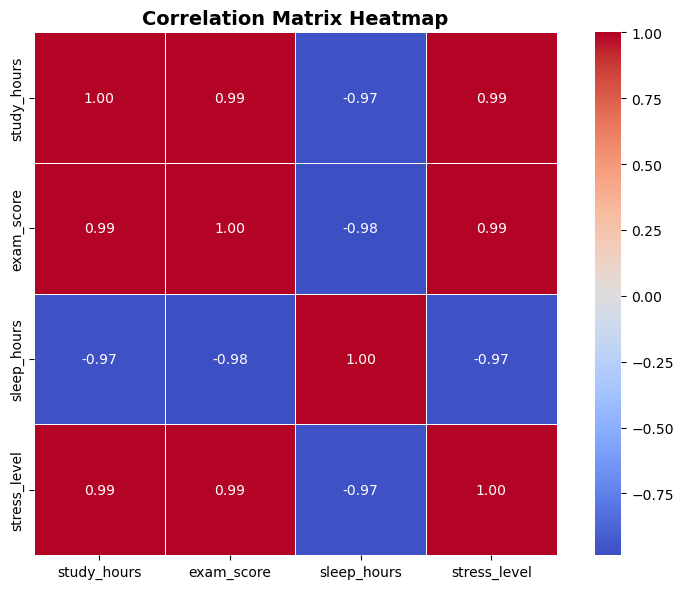

In [42]:
# ── 6. Correlation Heatmap ────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_study.corr(),
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


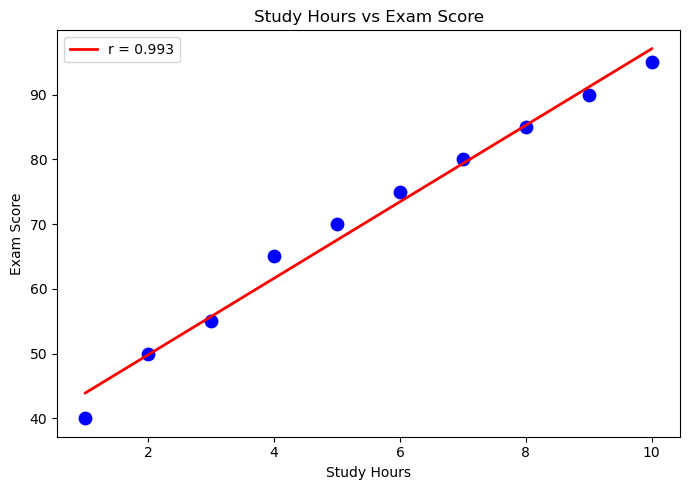

In [45]:
# ── 7. Scatter Plot with Regression Line ─────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(df_study['study_hours'], df_study['exam_score'], color='blue', s=80)
m, b = np.polyfit(df_study['study_hours'], df_study['exam_score'], 1)
x_line = np.linspace(df_study['study_hours'].min(), df_study['study_hours'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', lw=2, label=f'r = {r:.3f}')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')
plt.legend()
plt.tight_layout()
plt.savefig('scatter_correlation.png', dpi=150, bbox_inches='tight')
plt.show()